<a href="https://colab.research.google.com/github/joysujeeth1761/Adversarial_ML/blob/main/SCORE_BASED_ATTACKS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
#LOADING MINST DATASET
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("MNIST Loaded")

100%|██████████| 9.91M/9.91M [00:00<00:00, 42.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]

MNIST Loaded


In [3]:
#build CNN model
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model Initialized")

Model Initialized


In [5]:
#train CNN
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

print("Training Completed")


Epoch 1, Loss: 167.1282
Epoch 2, Loss: 47.9367
Epoch 3, Loss: 33.3098
Training Completed


In [6]:
#visulaization function
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()

**NES (Natural Evolution Strategies)**

In [7]:
#NES function
def nes_attack(model,
               image,
               label,
               epsilon=0.3,
               alpha=0.01,
               sigma=0.001,
               samples=50,
               iterations=20):

    model.eval()

    adv_image = image.clone().detach()

    for iteration in range(iterations):

        gradient_estimate = torch.zeros_like(
            adv_image
        )

        # Estimate gradient using random noise
        for _ in range(samples):

            noise = torch.randn_like(adv_image)

            # Positive perturbation
            image_pos = adv_image + sigma * noise

            output_pos = model(image_pos)

            loss_pos = loss_fn(
                output_pos,
                label
            )

            # Negative perturbation
            image_neg = adv_image - sigma * noise

            output_neg = model(image_neg)

            loss_neg = loss_fn(
                output_neg,
                label
            )

            # NES gradient estimate
            gradient_estimate += (
                (loss_pos - loss_neg)
                * noise
            )

        gradient_estimate /= (
            2 * sigma * samples
        )

        # Update adversarial image
        adv_image = (
            adv_image
            + alpha
            * gradient_estimate.sign()
        )

        # Projection step
        eta = torch.clamp(
            adv_image - image,
            min=-epsilon,
            max=epsilon
        )

        adv_image = image + eta

        adv_image = torch.clamp(
            adv_image,
            0,
            1
        ).detach()

    return adv_image.detach()

In [8]:
#generate NES adversial example
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = nes_attack(
    model,
    images,
    labels
)

print("NES Attack Completed")

NES Attack Completed


In [9]:
#compare predoctions
output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmin(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 2
Adversarial Prediction: 6


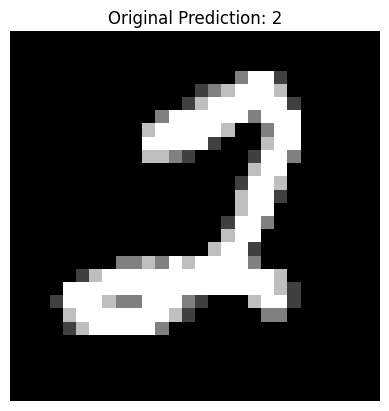

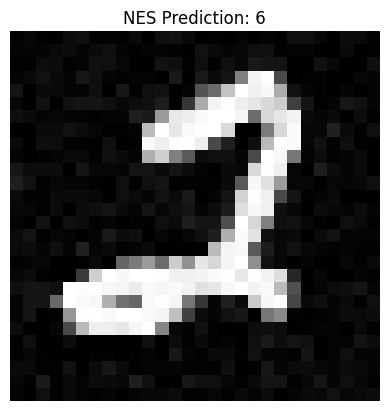

In [10]:
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"NES Prediction: {pred2.item()}"
)

In [13]:
def test_nes(model,
             loader,
             epsilon=0.1):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        adv_images = nes_attack(
            model,
            images,
            labels,
            epsilon=epsilon
        )

        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(f"NES Accuracy: {accuracy:.2f}%")

In [14]:
test_nes(model, test_loader)

KeyboardInterrupt: 

**ZOO(zeroth order optimization attacks)**

In [15]:
def zoo_attack(model,
               image,
               label,
               epsilon=0.3,
               alpha=0.01,
               h=0.001,
               iterations=20):

    model.eval()

    adv_image = image.clone().detach()

    for iteration in range(iterations):

        gradient_estimate = torch.zeros_like(
            adv_image
        )

        # Estimate gradient pixel-by-pixel
        for i in range(adv_image.numel()):

            # Create perturbation tensor
            perturb = torch.zeros_like(
                adv_image
            )

            perturb.view(-1)[i] = h

            # Positive perturbation
            image_pos = adv_image + perturb

            output_pos = model(image_pos)

            loss_pos = loss_fn(
                output_pos,
                label
            )

            # Negative perturbation
            image_neg = adv_image - perturb

            output_neg = model(image_neg)

            loss_neg = loss_fn(
                output_neg,
                label
            )

            # Finite difference estimate
            grad_i = (
                loss_pos - loss_neg
            ) / (2 * h)

            gradient_estimate.view(-1)[i] = grad_i

        # Update adversarial image
        adv_image = (
            adv_image
            + alpha
            * gradient_estimate.sign()
        )

        # Projection step
        eta = torch.clamp(
            adv_image - image,
            min=-epsilon,
            max=epsilon
        )

        adv_image = image + eta

        adv_image = torch.clamp(
            adv_image,
            0,
            1
        ).detach()

    return adv_image.detach()

In [24]:
#generate ZOO adversial example
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = zoo_attack(
    model,
    images,
    labels
)

print("ZOO Attack Completed")

ZOO Attack Completed


In [23]:
#compare predictions
output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 8
Adversarial Prediction: 8


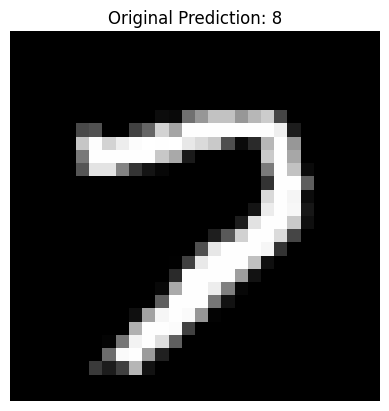

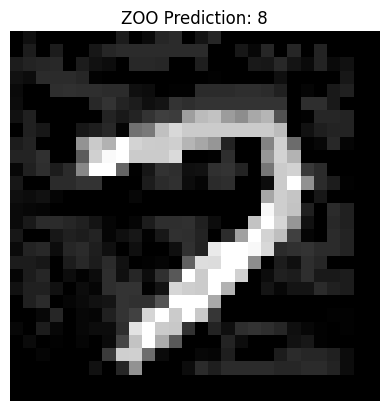

In [25]:
#visualization fuction
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"ZOO Prediction: {pred2.item()}"
)

In [28]:
#accuracy of ZOO attack
def test_zoo(model,
             loader,
             epsilon=0.01):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        adv_images = zoo_attack(
            model,
            images,
            labels,
            epsilon=epsilon
        )

        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(f"ZOO Accuracy: {accuracy:.2f}%")

In [29]:

test_zoo(model, test_loader)
# around 5% accuracy

KeyboardInterrupt: 